# MÉTODO DEL PUNTO FIJO

**Nombre:** *GOMEZ AGUIRRE ROCIO*  
**Fecha:** *08 de octubre de 2026*

---

## 1. Planteamiento del problema

Dada una función $g$, se quiere encontrar un número $p$ tal que

$$g(p) = p$$

A este número se le llama **punto fijo** de $g$.

### ¿Para qué sirve?

Resolver una ecuación $f(x) = 0$ es lo mismo que encontrar un punto fijo, si se despeja $x$ y se escribe la ecuación como $x = g(x)$.

El objetivo de este cuaderno es hacer un programa **general**: que reciba *cualquier* función $g$ y encuentre su punto fijo. Para comprobar que funciona bien, se prueba con el **Ejemplo 1 de Burden (p. 38)**:

$$f(x) = x^3 + 4x^2 - 10 = 0 \quad \text{en } [1, 2]$$

cuya solución se conoce, $p \approx 1.365230013$.

## 2. Descripción del método

Se empieza con un valor inicial $p_0$ y se calcula

$$p_1 = g(p_0), \quad p_2 = g(p_1), \quad p_3 = g(p_2), \dots$$

Se detiene cuando dos valores seguidos están muy cerca:

$$|p_n - p_{n-1}| < TOL$$


> **Nota:** el método no converge para cualquier forma de despejar $x$. Se necesita que $g$ cumpla el teorema del punto fijo: que $g(x)$ se quede dentro del intervalo $[a,b]$ y que $|g'(x)| \le k < 1$.

## 3. Programa en Python

### Librerías

In [9]:
import numpy as np                 # librería de matemáticas (la llamamos np)
import matplotlib.pyplot as plt    # librería para hacer gráficas (la llamamos plt)

### Función del método

`puntofijo` recibe la función `g`, el valor inicial `P0`, la tolerancia `tol` y el máximo de iteraciones `nmax`. Como `g` es un dato de entrada, se puede usar con **cualquier función**.

In [10]:
# def sirve para definir una función; entre paréntesis van los datos de entrada
def puntofijo(g, P0, tol, nmax):

    niter = 1                  # Paso 1: contador de iteraciones

    # Listas vacías para guardar los datos y después hacer gráficas
    lista_iter = []
    lista_error = []

    print("iter    Pn-1        Pn        error")

    # while repite lo que está adentro mientras se cumpla la condición
    while niter <= nmax:       # Paso 2
        P = g(P0)              # Paso 3: se calcula el nuevo valor
        error = abs(P - P0)    # abs es el valor absoluto

        # round(número, 6) redondea a 6 decimales
        print(niter, "   ", round(P0, 6), "   ", round(P, 6), "   ", round(error, 6))

        lista_iter.append(niter)       # append agrega un dato al final de la lista
        lista_error.append(error)

        # Paso 4: si el error ya es menor que la tolerancia, se termina
        if error < tol:
            print("\nEl procedimiento fue exitoso después de", niter, "iteraciones")
            return P, lista_iter, lista_error     # return regresa los resultados

        niter += 1             # Paso 5 (es lo mismo que niter = niter + 1)
        P0 = P                 # Paso 6: el nuevo valor será el anterior en la siguiente vuelta

    # Paso 7: si el ciclo termina sin haber hecho return, el método falló
    print("El método falló después de", nmax, "iteraciones")
    return None, lista_iter, lista_error

## 4. Prueba con el Ejemplo 1 de Burden (p. 38)

Para comprobar el programa se usa la ecuación $x^3 + 4x^2 - 10 = 0$. Al despejar:

$$x^3 + 4x^2 - 10 = 0 \;\Rightarrow\; x^2(x+4) = 10 \;\Rightarrow\; x = \sqrt{\frac{10}{x+4}}$$

Entonces la función que se le da al programa es

$$g(x) = \sqrt{\frac{10}{x+4}}$$

Se cumplen las condiciones del teorema en $[1,2]$: $g(1) \approx 1.4142$ y $g(2) \approx 1.2910$ están dentro de $[1,2]$, y $|g'(x)| \le 0.1414 < 1$.

In [11]:
# Esta es la función que queremos probar (np.sqrt calcula la raíz cuadrada)
def g(x):
    return np.sqrt(10 / (x + 4))

# Datos de entrada
P0 = 1.5        # valor inicial (el punto medio del intervalo [1, 2])
tol = 10**-5    # tolerancia (** es la potencia, así que es 10 elevado a -5)
nmax = 100      # número máximo de iteraciones

# Se llama a la función; regresa la solución y las dos listas
P, lista_iter, lista_error = puntofijo(g, P0, tol, nmax)

iter    Pn-1        Pn        error
1     1.5     1.3484     0.1516
2     1.3484     1.367376     0.018977
3     1.367376     1.364957     0.002419
4     1.364957     1.365265     0.000308
5     1.365265     1.365226     3.9e-05
6     1.365226     1.365231     5e-06

El procedimiento fue exitoso después de 6 iteraciones


### Solución final

In [12]:
print("SOLUCIÓN FINAL:  p =", round(P, 7))
print("Comprobación: g(p) =", round(g(P), 7))
print("Comprobación: f(p) =", P**3 + 4*P**2 - 10)

SOLUCIÓN FINAL:  p = 1.3652306
Comprobación: g(p) = 1.3652299
Comprobación: f(p) = 9.28481537343373e-06


### Gráfica del punto fijo

El punto fijo es donde la curva $y = g(x)$ se cruza con la recta $y = x$.

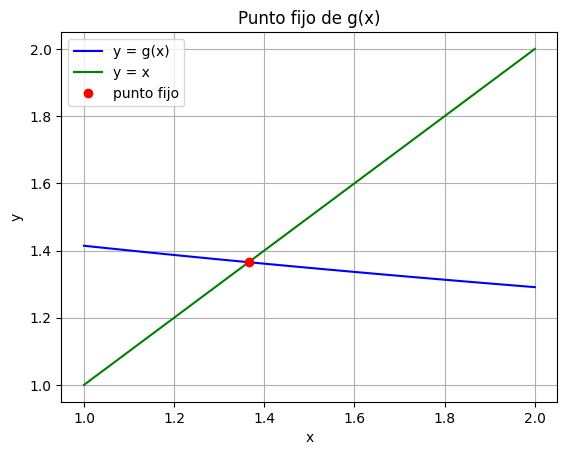

In [13]:
x = np.linspace(1, 2, 100)     # 100 valores de x entre 1 y 2

plt.plot(x, g(x), color="blue", label="y = g(x)")   # curva azul
plt.plot(x, x, color="green", label="y = x")        # recta verde
plt.plot(P, P, "ro", label="punto fijo")            # punto rojo ("r" = rojo, "o" = círculo)
plt.title("Punto fijo de g(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()     # muestra los nombres de cada línea
plt.grid()       # agrega la cuadrícula
plt.show()       # muestra la gráfica

### Error en cada iteración

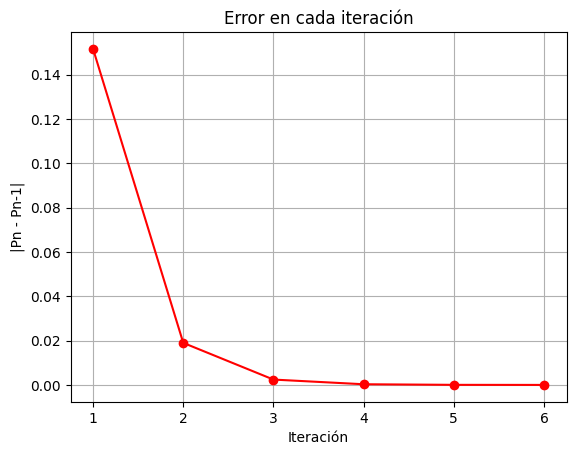

In [14]:
plt.plot(lista_iter, lista_error, "o-", color="red")   # "o-" = puntos unidos con línea
plt.title("Error en cada iteración")
plt.xlabel("Iteración")
plt.ylabel("|Pn - Pn-1|")
plt.grid()
plt.show()

## 5. Otra prueba con una función distinta

Para mostrar que el programa sirve con cualquier función, se prueba con

$$g(x) = \cos(x)$$

cuyo punto fijo es la solución de $\cos(x) = x$ (se sabe que es $p \approx 0.7390851$).

In [15]:
# Otra función g distinta: solo hay que cambiar esta parte
def g2(x):
    return np.cos(x)

P2, iter2, error2 = puntofijo(g2, 1.0, 10**-5, 100)

print("\nSOLUCIÓN FINAL:  p =", round(P2, 7))

iter    Pn-1        Pn        error
1     1.0     0.540302     0.459698
2     0.540302     0.857553     0.317251
3     0.857553     0.65429     0.203263
4     0.65429     0.79348     0.139191
5     0.79348     0.701369     0.092112
6     0.701369     0.76396     0.062591
7     0.76396     0.722102     0.041857
8     0.722102     0.750418     0.028315
9     0.750418     0.731404     0.019014
10     0.731404     0.744237     0.012833
11     0.744237     0.735605     0.008633
12     0.735605     0.741425     0.00582
13     0.741425     0.737507     0.003918
14     0.737507     0.740147     0.00264
15     0.740147     0.738369     0.001778
16     0.738369     0.739567     0.001198
17     0.739567     0.73876     0.000807
18     0.73876     0.739304     0.000544
19     0.739304     0.738938     0.000366
20     0.738938     0.739184     0.000247
21     0.739184     0.739018     0.000166
22     0.739018     0.73913     0.000112
23     0.73913     0.739055     7.5e-05
24     0.739055     0.739

## 6. Conclusiones

- Se programó el método del punto fijo como una función `puntofijo(g, P0, tol, nmax)` que sirve para **cualquier función** $g$: solo hay que cambiar la `g` y los datos de entrada.
- Con el Ejemplo 1 de Burden ($g(x)=\sqrt{10/(x+4)}$) se obtuvo $p \approx 1.36523$ en 6 iteraciones, lo que coincide con el libro y confirma que el programa es correcto.
- Con $g(x)=\cos(x)$ también se encontró el punto fijo, $p \approx 0.73908$ (coincide con el valor exacto 0.7390851 hasta la tolerancia usada).
- El método solo converge si $g$ cumple las condiciones del teorema; por eso importa la forma en que se despeja $x$. Si no converge, el programa muestra el mensaje de falla.